Comparing Kernels...

--- Final Model Results ---
Accuracy: 0.9945753309223693
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.19      0.67      0.30        98

    accuracy                           0.99     56962
   macro avg       0.60      0.83      0.65     56962
weighted avg       1.00      0.99      1.00     56962



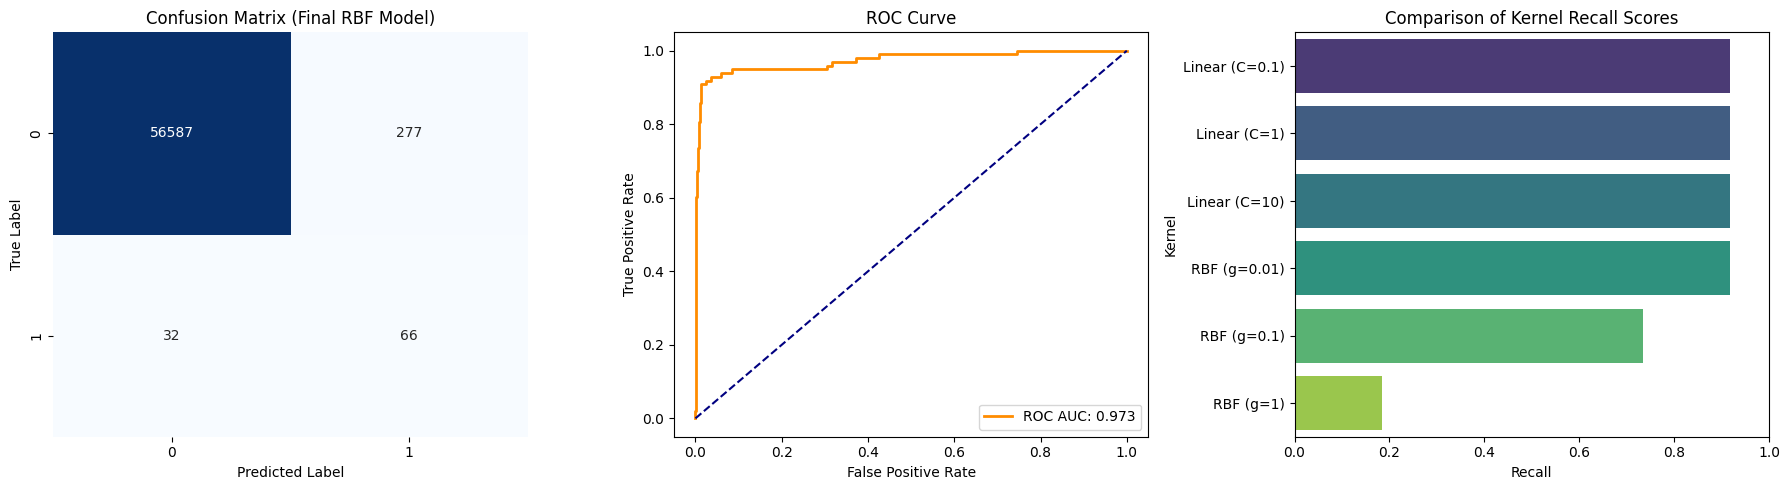

In [25]:
# Support Vector Machine (SVM)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import shuffle
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, roc_curve


# Load preprocessed data
X_train_resampled = pd.read_csv("X_train_resampled.csv")
y_train_resampled = pd.read_csv("y_train_resampled.csv").values.ravel()

X_test = pd.read_csv("X_test.csv")
y_test = pd.read_csv("y_test.csv").values.ravel()


# Kernel Experimentation
X_sample, y_sample = shuffle(X_train_resampled, y_train_resampled, random_state=42)
X_sample = X_sample[:10000]
y_sample = y_sample[:10000]

results = []

print("Comparing Kernels...")
# Linear kernel experimentation
for C in [0.1, 1, 10]:
    model = SVC(kernel='linear', C=C)
    model.fit(X_sample, y_sample)
    y_pred = model.predict(X_test)
    rec = classification_report(y_test, y_pred, output_dict=True)['1']['recall']
    results.append({'Kernel': f'Linear (C={C})', 'Recall': rec})

# RBF kernel experimentation
for gamma in [0.01, 0.1, 1]:
    model = SVC(kernel='rbf', C=1.0, gamma=gamma)
    model.fit(X_sample, y_sample)
    y_pred = model.predict(X_test)
    rec = classification_report(y_test, y_pred, output_dict=True)['1']['recall']
    results.append({'Kernel': f'RBF (g={gamma})', 'Recall': rec})


# Final Model Training & Full Evaluation
X_final_train, y_final_train = shuffle(X_train_resampled, y_train_resampled, random_state=42)
X_final_train = X_final_train[:20000]
y_final_train = y_final_train[:20000]

final_model = SVC(kernel='rbf', C=1.0, gamma=0.1, probability=True)
final_model.fit(X_final_train, y_final_train)

y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:, 1]

print("\n--- Final Model Results ---")
print("Accuracy:", accuracy_score(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))

# Visualizations for Demo/Presentation
plt.figure(figsize=(18, 5))

# Plot 1: Confusion Matrix Heatmap
plt.subplot(1, 3, 1)
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Final RBF Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Plot 2: ROC Curve
plt.subplot(1, 3, 2)
fpr, tpr, _ = roc_curve(y_test, y_prob_final)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC AUC: {roc_auc_score(y_test, y_prob_final):.3f}')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")

# Plot 3: Kernel Comparison (Recall)
plt.subplot(1, 3, 3)
res_df = pd.DataFrame(results)
# Fixed FutureWarning: Added hue='Kernel' and legend=False
sns.barplot(x='Recall', y='Kernel', data=res_df, hue='Kernel', palette='viridis', legend=False)
plt.xlim(0, 1)
plt.title('Comparison of Kernel Recall Scores')
plt.tight_layout()
plt.show()